# **Stochastic Gradient Descent**

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing()
df=pd.DataFrame(housing.data,columns=housing.feature_names)
df['target']=housing.target
df.head()


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [3]:
X=df.iloc[:,0:7]
y=df.iloc[:,-1]

In [4]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [5]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

0.5138753320387439

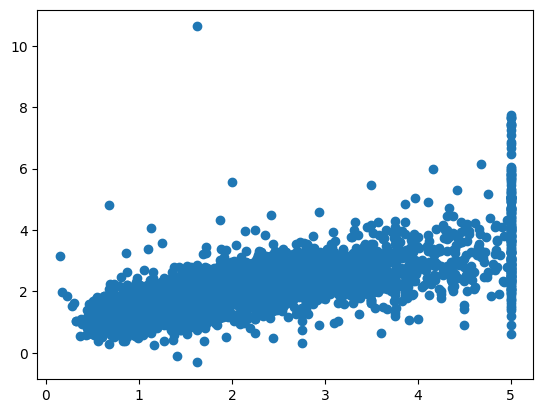

In [7]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
lr=LinearRegression()
lr.fit(X_train,y_train)
lr.predict(X_test)
plt.scatter(y_test,lr.predict(X_test))
r2_score(y_test,lr.predict(X_test))

In [8]:
class SGDRegressor:
    def __init__(self, learning_rate=0.01, epochs=100):
        self.lr = learning_rate
        self.epochs = epochs
        self.coef_ = None
        self.intercept_ = 0

    def fit(self, X_train, y_train):
        X_train = np.array(X_train)
        y_train = np.array(y_train)

        if X_train.ndim == 1:
            X_train = X_train.reshape(-1, 1)

        n, m = X_train.shape

        self.coef_ = np.zeros(m)
        self.intercept_ = 0

        for i in range(self.epochs):
            for j in range(n):
                idx = np.random.randint(n)

                x = X_train[idx]
                y = y_train[idx]

                y_pred = np.dot(x, self.coef_) + self.intercept_

                dcoef = 2 * (y_pred - y) * x
                dintercept = 2 * (y_pred - y)

                self.coef_ -= self.lr * dcoef
                self.intercept_ -= self.lr * dintercept

    def predict(self, X_test):
        X_test = np.array(X_test)

        if X_test.ndim == 1:
            X_test = X_test.reshape(-1, 1)

        return np.dot(X_test, self.coef_) + self.intercept_

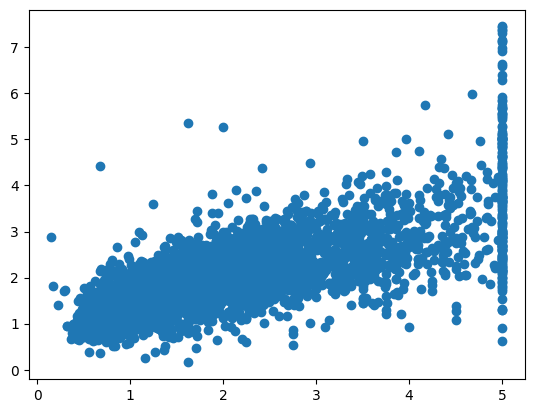

0.5194555118296843

In [12]:
sgd = SGDRegressor(learning_rate=0.00001, epochs=40)
sgd.fit(X_train, y_train)

y_pred = sgd.predict(X_test)
plt.scatter(y_test, y_pred)
plt.show()
r2_score(y_test, y_pred)

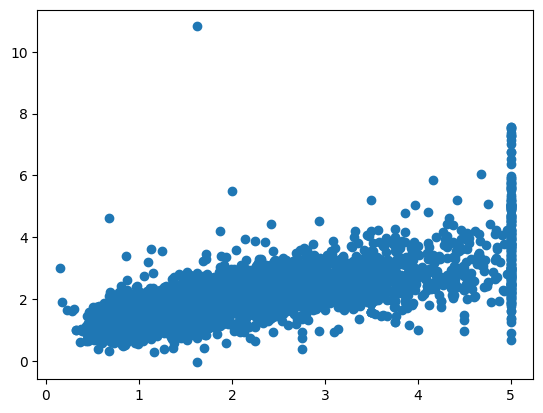

0.5111954340998757

In [15]:
from sklearn.linear_model import SGDRegressor
sg=SGDRegressor(max_iter=40,learning_rate='constant',eta0=0.0001)
sg.fit(X_train,y_train)
y_pred=sg.predict(X_test)
plt.scatter(y_test,y_pred)
plt.show()
r2_score(y_test,y_pred)